<a href="https://www.kaggle.com/code/chauhanadityacse/eye-of-the-machine?scriptVersionId=268900577" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/glaucoma-detection/glaucoma.csv
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/537.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/521.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/539.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/501.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/544.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/489.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/576.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/503.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms


# Prepare Glaucoma Dataset

In [3]:
# Paths to Glaucoma images
GLAUCOMA_PATHS = [
    "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Train/Glaucoma_Negative",
    "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Train/Glaucoma_Positive",
    "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative",
    "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Positive"
]

# Collect images and labels
all_samples = []
for path in GLAUCOMA_PATHS:
    label = 0 if "Negative" in path else 1
    for f in os.listdir(path):
        if f.lower().endswith((".jpg",".jpeg",".png")):
            all_samples.append( (os.path.join(path,f), label) )

print(f"Total samples: {len(all_samples)}")

# Transformations with augmentation
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64,64)),      # larger size for better features
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Dataset class
class GlaucomaDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


Total samples: 650


# Train/Validatin Split

In [4]:
# Split dataset 80/20
dataset = GlaucomaDataset(all_samples, transform=transform_train)
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Update validation transform
val_dataset.dataset.transform = transform_val

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")


Train: 520, Val: 130


# Visualize Some Images

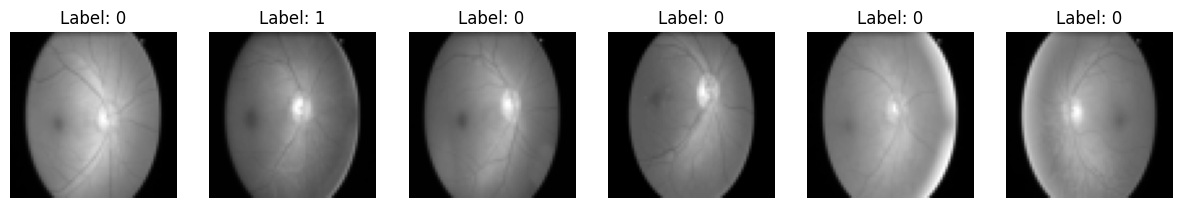

In [5]:
def show_samples(loader, n=6):
    imgs, labels = next(iter(loader))
    fig, axes = plt.subplots(1, n, figsize=(15,3))
    for i in range(n):
        img = imgs[i].squeeze(0)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {labels[i].item()}")
        axes[i].axis('off')
    plt.show()

show_samples(train_loader)


# LeNet Model

In [6]:
class LeNet(nn.Module):
    def __init__(self, num_classes=2):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.AvgPool2d(2,2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16*13*13, 120)  # 64x64 input
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
        self.relu = nn.ReLU()
    
    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
model = LeNet().to(device)
print(model)


LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=2704, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=2, bias=True)
  (relu): ReLU()
)


# Weighted Loss (Class Imbalance)

In [7]:
# Compute class weights
labels = [label for _, label in all_samples]
class_counts = np.bincount(labels)
class_weights = 1.0 / class_counts
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training Loop

In [8]:
epochs = 20
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss/len(train_loader))
    
    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_losses.append(val_loss/len(val_loader))
    acc = 100*correct/total
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {acc:.2f}%")


Epoch 1/20 | Train Loss: 0.6972 | Val Loss: 0.6829 | Val Acc: 83.08%
Epoch 2/20 | Train Loss: 0.6938 | Val Loss: 0.6952 | Val Acc: 19.23%
Epoch 3/20 | Train Loss: 0.6939 | Val Loss: 0.6881 | Val Acc: 67.69%
Epoch 4/20 | Train Loss: 0.6886 | Val Loss: 0.6776 | Val Acc: 57.69%
Epoch 5/20 | Train Loss: 0.6707 | Val Loss: 0.6666 | Val Acc: 53.08%
Epoch 6/20 | Train Loss: 0.6548 | Val Loss: 0.6458 | Val Acc: 62.31%
Epoch 7/20 | Train Loss: 0.6343 | Val Loss: 0.6634 | Val Acc: 53.85%
Epoch 8/20 | Train Loss: 0.6483 | Val Loss: 0.6495 | Val Acc: 62.31%
Epoch 9/20 | Train Loss: 0.6048 | Val Loss: 0.6137 | Val Acc: 66.92%
Epoch 10/20 | Train Loss: 0.6359 | Val Loss: 0.7066 | Val Acc: 36.92%
Epoch 11/20 | Train Loss: 0.6169 | Val Loss: 0.6606 | Val Acc: 56.15%
Epoch 12/20 | Train Loss: 0.5840 | Val Loss: 0.6539 | Val Acc: 57.69%
Epoch 13/20 | Train Loss: 0.5719 | Val Loss: 0.6114 | Val Acc: 63.85%
Epoch 14/20 | Train Loss: 0.5592 | Val Loss: 0.6535 | Val Acc: 60.77%
Epoch 15/20 | Train Loss: 0.5

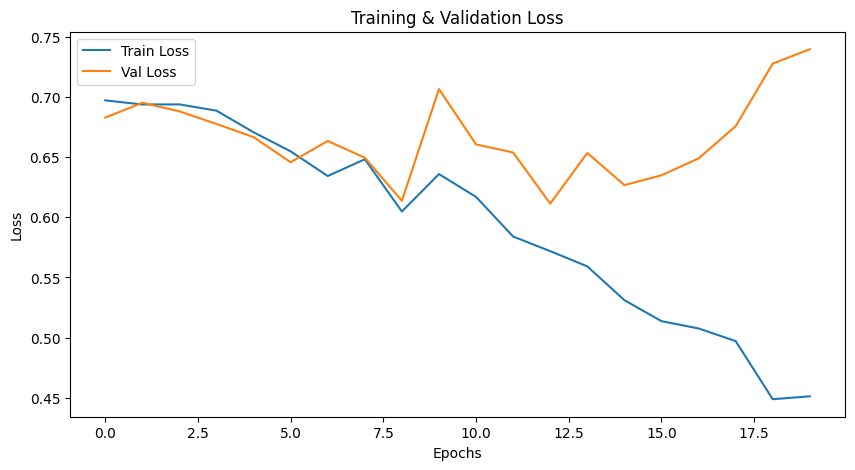

In [9]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()


# Save Model

In [10]:
torch.save(model.state_dict(), "lenet_glaucoma.pth")
print("Model saved!")


Model saved!


# Load & Test Model

In [11]:
# Load
model = LeNet().to(device)
model.load_state_dict(torch.load("lenet_glaucoma.pth", map_location=device))
model.eval()
print("Model loaded for testing!")

# Test accuracy
correct = 0
total = 0
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Validation Accuracy: {100*correct/total:.2f}%")


Model loaded for testing!
Validation Accuracy: 50.77%


# Sample Prediction

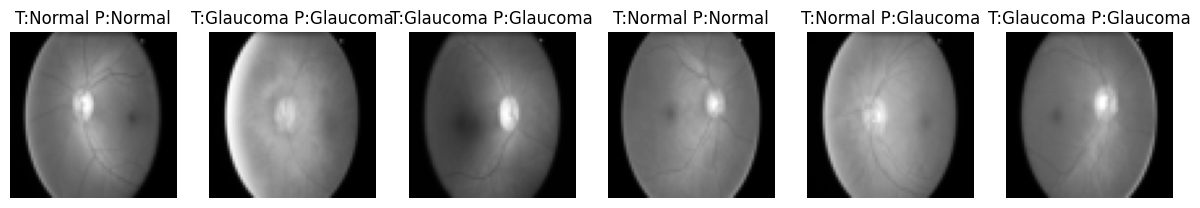

In [12]:
class_names = {0:"Normal", 1:"Glaucoma"}

def show_predictions(loader, model, n=6):
    imgs, labels = next(iter(loader))
    imgs, labels = imgs.to(device), labels.to(device)
    outputs = model(imgs)
    _, predicted = torch.max(outputs,1)
    
    fig, axes = plt.subplots(1,n,figsize=(15,3))
    for i in range(n):
        img = imgs[i].cpu().squeeze(0)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"T:{class_names[labels[i].item()]} P:{class_names[predicted[i].item()]}")
        axes[i].axis('off')
    plt.show()

show_predictions(val_loader, model)
